# Riffs

## Setup

### Import Libraries

In [44]:
# import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, jensenshannon
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='white')
os.makedirs('plots', exist_ok=True)

### Load Data

In [45]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
THETA = pd.read_csv('data/LDA_THETA.csv', sep='\t').set_index(['book_id', 'chap_num'])
PHI = pd.read_csv('data/LDA_PHI.csv', sep='\t').set_index('topic_id')
TOPICS = pd.read_csv('data/LDA_TOPICS.csv', sep='\t').set_index('topic_id')
VOCAB_W2V = pd.read_csv('data/VOCAB_W2V.csv', sep='\t').set_index('term_str')
DCM = pd.read_csv('data/PCA_DCM.csv', sep='\t').set_index(['book_id', 'chap_num'])
LOADINGS = pd.read_csv('data/PCA_LOADINGS.csv', sep='\t').set_index('term_str')

## Riff 1: Hierarchical Clustering of Books by LDA Topic Profile

### Aggregate THETA to Book Level

In [46]:
THETA_BOOKS = THETA.groupby('book_id').mean() # use mean not sum because raw aggregation is sensitive to document size

### Compute Pairwise Jensen-Shannon Distance

Note that unlike TFIDF in the M06 Clustering notes, my THETA table is already a probability distribution (doc-topic) where each row sums to ~1 so I do not need a normalization step.

In [47]:
# create condensed distance matrix (list of pair distances as flat 1D array that leaves out the diagonal (A to A = 0) and the lower triangle (redundant A to B = B to A))
# so instead of a 22x22 matrix, I get an array of 22x21/2 = 231 values
condensed = pdist(THETA_BOOKS, 'jensenshannon') # use jensen shannon for distance

### Cluster and Visualize

In [48]:
# create short titles for the leaves
short_titles = {
    'giants-bread':                              "Giant's Bread *",
    'the-adventure-of-the-cheap-flat':           'PI: Cheap Flat',
    'the-adventure-of-the-egyptian-tomb':        'PI: Egyptian Tomb',
    'the-adventure-of-the-italian-nobleman':     'PI: Italian Nobleman',
    'the-adventure-of-the-western-star':         'PI: Western Star',
    'the-big-four':                              'The Big Four',
    'the-case-of-the-missing-will':              'PI: Missing Will',
    'the-disappearance-of-mr-davenheim':         'PI: Davenheim',
    'the-jewel-robbery-at-the-grand-metropolitan': 'PI: Grand Metropolitan',
    'the-kidnapped-prime-minister':              'PI: Prime Minister',
    'the-man-in-the-brown-suit':                 'Man in the Brown Suit',
    'the-million-dollar-bond-robbery':           'PI: Bond Robbery',
    'the-murder-at-the-vicarage':                'Murder at the Vicarage',
    'the-murder-of-roger-ackroyd':               'Roger Ackroyd',
    'the-murder-on-the-links':                   'Murder on the Links',
    'the-mysterious-affair-at-styles':           'Styles',
    'the-mystery-of-hunters-lodge':              'PI: Hunters Lodge',
    'the-mystery-of-the-blue-train':             'Blue Train',
    'the-secret-adversary':                      'Secret Adversary',
    'the-secret-of-chimneys':                    'Secret of Chimneys',
    'the-seven-dials-mystery':                   'Seven Dials Mystery',
    'the-tragedy-at-marsdon-manor':              'PI: Marsdon Manor',
}

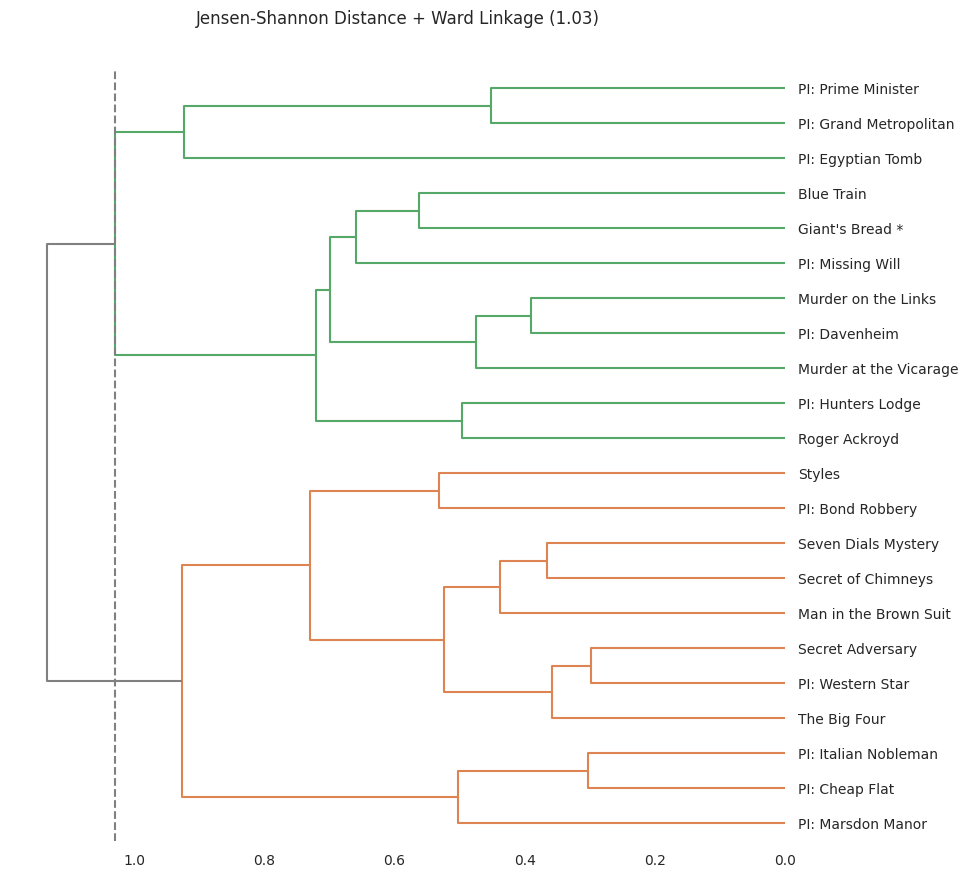

In [49]:
# Generate the cluster tree
tree = sch.linkage(condensed, method='ward')

# Get short titles as labels for the leaves
labels = [short_titles[i] for i in THETA_BOOKS.index]

# choose color_threshold
color_thresh = 1.03

# Create a dendrogram from the tree and plot
plt.figure(figsize=(10, 10))
sch.dendrogram(
    tree, 
    labels=labels, 
    orientation="left", 
    distance_sort=True,
    above_threshold_color='gray',
    color_threshold=color_thresh
)

# Show threshhold
plt.gca().axvline(color_thresh, c='gray', ls='--')

# Change the appearance of ticks, tick labels, and gridlines
plt.tick_params(axis='both', which='major', labelsize=10)    

# Remove borders
sns.despine(left=True, bottom=True)

# Add title
plt.title(f"Jensen-Shannon Distance + Ward Linkage ({color_thresh})", y=1.05)

plt.savefig('plots/riff1_dendrogram.png', dpi=300, bbox_inches='tight')

In [50]:
assignments = sch.fcluster(tree, t=3, criterion='maxclust')
for book, cluster in sorted(zip(labels, assignments), key=lambda x: x[1]):
    print(f'{cluster}\t{book}')

1	PI: Cheap Flat
1	PI: Italian Nobleman
1	PI: Western Star
1	The Big Four
1	Man in the Brown Suit
1	PI: Bond Robbery
1	Styles
1	Secret Adversary
1	Secret of Chimneys
1	Seven Dials Mystery
1	PI: Marsdon Manor
2	Giant's Bread *
2	PI: Missing Will
2	PI: Davenheim
2	Murder at the Vicarage
2	Roger Ackroyd
2	Murder on the Links
2	PI: Hunters Lodge
2	Blue Train
3	PI: Egyptian Tomb
3	PI: Grand Metropolitan
3	PI: Prime Minister


### Interpretation

#### Topic Distributions by Cluster

In [51]:
# compare mean topic weights across clusters to identify what drives the separation
cluster1 = ['the-adventure-of-the-cheap-flat', 'the-adventure-of-the-italian-nobleman',
            'the-adventure-of-the-western-star', 'the-big-four', 'the-man-in-the-brown-suit',
            'the-million-dollar-bond-robbery', 'the-mysterious-affair-at-styles',
            'the-secret-adversary', 'the-secret-of-chimneys', 'the-seven-dials-mystery',
            'the-tragedy-at-marsdon-manor']

cluster2 = ['giants-bread', 'the-case-of-the-missing-will', 'the-disappearance-of-mr-davenheim',
            'the-murder-at-the-vicarage', 'the-murder-of-roger-ackroyd',
            'the-murder-on-the-links', 'the-mystery-of-hunters-lodge',
            'the-mystery-of-the-blue-train']

pd.DataFrame({
    'cluster1_mean': THETA_BOOKS.loc[cluster1].mean(),
    'cluster2_mean': THETA_BOOKS.loc[cluster2].mean(),
    'diff': THETA_BOOKS.loc[cluster1].mean() - THETA_BOOKS.loc[cluster2].mean()
}).rename(index=lambda x: int(x)).join(TOPICS[['label', 'theme']]).sort_values('diff')

,cluster1_mean,cluster2_mean,diff,label,theme
4,0.010954,0.203666,-0.192712,Inheritance & Family Finance,Motive
13,0.037978,0.144578,-0.106601,Official Legal Investigation,Investigation
9,0.023960,0.095475,-0.071515,Collaborative Law Enforcement,Investigation
11,0.054409,0.100040,-0.045631,Domestic & Family Units,Prose Infrastructure
2,0.009757,0.041962,-0.032205,Wealthy Estate Settings,Genre Trope
6,0.048070,0.053181,-0.005112,High-Value Theft & Travel,Genre Trope
1,0.111057,0.110838,0.000219,General Social Narrative,Prose Infrastructure
5,0.008603,0.005368,0.003235,Romantic / Sentimental Narrative,Genre Trope
14,0.040962,0.035967,0.004995,Private Papers & Evidence,Clues
8,0.026479,0.015017,0.011462,Life History & Mortality,Background


In [52]:
theme_map = {str(k): v for k, v in TOPICS['theme'].to_dict().items()}

THETA_BOOKS_THEMES = THETA_BOOKS.rename(columns=theme_map).T.groupby(level=0).sum().T

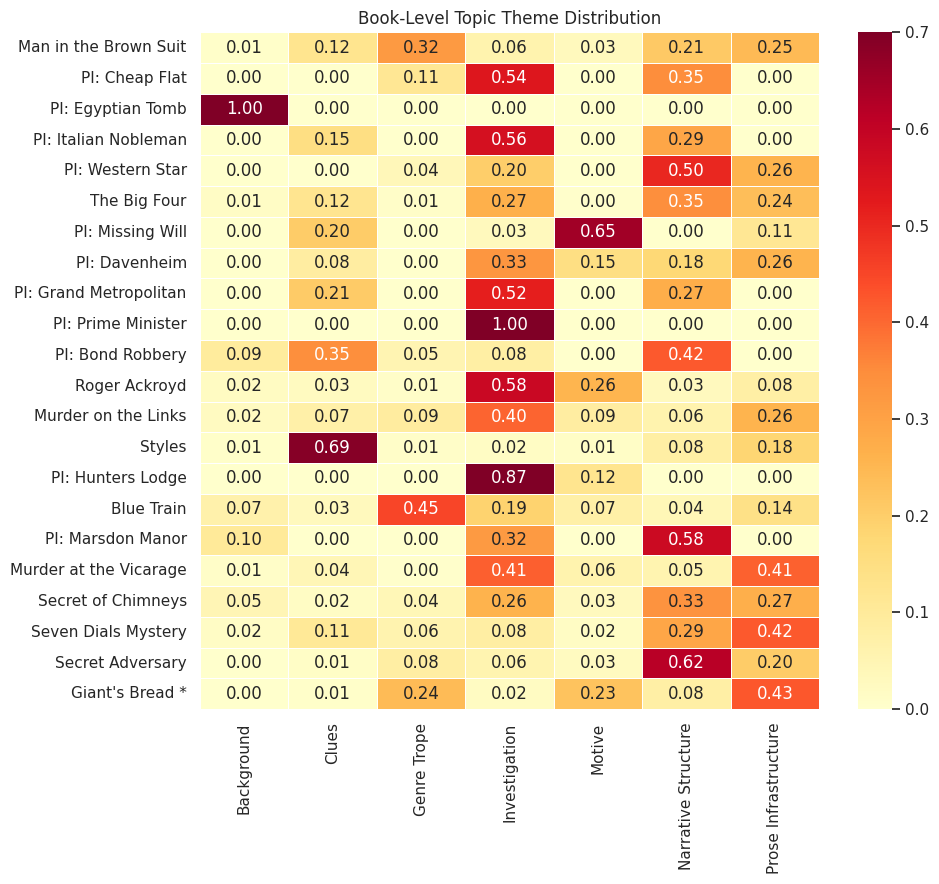

In [53]:
# theme by book heat map

# build display version with short titles, sorted by sleuth
display = THETA_BOOKS_THEMES.copy()
display.index = [short_titles[i] for i in display.index]

# sort rows by sleuth group using LIB
sleuth_order = LIB['sleuth'].fillna('Westmacott').to_dict()
row_order = sorted(THETA_BOOKS.index, key=lambda b: str(sleuth_order.get(b, 'z')))
display = display.loc[[short_titles[r] for r in row_order]]

plt.figure(figsize=(10, 9))
sns.heatmap(display, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=0.7)
plt.title('Book-Level Topic Theme Distribution')
plt.tight_layout()
plt.savefig('plots/riff1_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

The above heatmap is a supporting visualization for the dendrogram. It shows the topic themes underlying the clustering structure.

The dendrogram consists of two major clusters. The orange cluster is made up of most of the Poirot short stories plus the adventure/thriller novels. This group is connected by high weights in topics associated with narrative momentum and physical clue work -- the medical/physical discovery and administrative correspondence topics. The green cluster is made up of full length puzzle novels plus Giant's Bread (a non mystery work) and a few short stories. These are tied together by two backbone topics of fair play mysteries: the Inheritance & Family Finance and the Official Legal Investigation topics.

The split tracks not just format but the two dominant narrative modes of Agatha Christie: episodic clue-driven plots vs socially embedded crime narratives where the investigation is structured by legal processes and motive.

## Riff 2: Character Embedding Neighborhoods

### Select Target Characters

In [54]:
target_chars = ['poirot', 'hastings', 'japp', 'georges', 'giraud',
                'marple', 'clement', 'griselda',
                'tommy', 'tuppence',
                'battle', 'bundle', 'caterham', 'eversleigh',
                'race', 'pedler']

# map character to sleuth (from LIB)
char_to_sleuth = {
    'poirot':   'Hercule Poirot',
    'hastings': 'Hercule Poirot',
    'japp':     'Hercule Poirot',
    'georges':  'Hercule Poirot',
    'giraud':   'Hercule Poirot',
    'marple':   'Miss Jane Marple',
    'clement':  'Miss Jane Marple',
    'griselda': 'Miss Jane Marple',
    'tommy':    'Tommy and Tuppence',
    'tuppence': 'Tommy and Tuppence',
    'race':     'Colonel Race',
    'pedler':    'Colonel Race',
    'battle':   'Superintendent Battle',
    'bundle':    'Superintendent Battle',
    'caterham':  'Superintendent Battle',
    'eversleigh': 'Superintendent Battle'
}

### Compute Nearest Neighbors by Cosine Similarity

In [55]:
# get vectors for target characters only
target_vecs = VOCAB_W2V.loc[target_chars]

# compute similarity from each target to all vocab terms
# result is shape (16, vocab_size)
SIM = pd.DataFrame(
    cosine_similarity(target_vecs, VOCAB_W2V),
    index=target_chars,
    columns=VOCAB_W2V.index
)

In [56]:
# get 16x10 table of nearest neighbor names
n = 10
NEIGHBORS = SIM.apply(lambda row: row.nlargest(n+1).iloc[1:].index.tolist(), axis=1) # iloc[1:] skips the character itself (similarity = 1)

### Visualize

Q: Do the embeddings separate Christie's narrative universes?

Hypothesis: I expect that it would given the different styles (and genres) of the detectives.

In [57]:
# get 16x16 cosine similarity matrix for the target characters
SIM_CHARS = SIM[target_chars]

# order characters by sleuth group
char_order = sorted(target_chars, key=lambda c: char_to_sleuth[c])
SIM_CHARS = SIM_CHARS.loc[char_order, char_order]

SIM_CHARS

term_str,race,pedler,poirot,hastings,japp,georges,giraud,marple,clement,griselda,battle,bundle,caterham,eversleigh,tommy,tuppence
race,1.000000,0.631766,0.259096,0.402306,0.553468,0.573875,0.561960,0.688708,0.729616,0.551309,0.489643,0.343201,0.561367,0.725468,0.328331,0.359737
pedler,0.631766,1.000000,0.324287,0.599153,0.761129,0.847353,0.597589,0.653890,0.667919,0.549803,0.568246,0.351682,0.715202,0.660605,0.380259,0.441123
poirot,0.259096,0.324287,1.000000,0.156023,0.626512,0.282015,0.759278,0.365539,0.247822,0.692695,0.686002,0.760591,0.351597,0.277110,0.777556,0.708302
hastings,0.402306,0.599153,0.156023,1.000000,0.353627,0.382094,0.333571,0.536658,0.674878,0.423038,0.367279,0.195586,0.429638,0.439175,0.012637,0.256133
japp,0.553468,0.761129,0.626512,0.353627,1.000000,0.675599,0.731977,0.631381,0.479674,0.746768,0.779820,0.685417,0.666290,0.559544,0.720534,0.717756
georges,0.573875,0.847353,0.282015,0.382094,0.675599,1.000000,0.585354,0.527225,0.545073,0.426754,0.365318,0.285832,0.496107,0.583322,0.349079,0.290159
giraud,0.561960,0.597589,0.759278,0.333571,0.731977,0.585354,1.000000,0.598985,0.511747,0.769740,0.717507,0.688969,0.520056,0.541659,0.733950,0.705119
marple,0.688708,0.653890,0.365539,0.536658,0.631381,0.527225,0.598985,1.000000,0.743029,0.593545,0.639218,0.423813,0.592317,0.731966,0.357655,0.658848
clement,0.729616,0.667919,0.247822,0.674878,0.479674,0.545073,0.511747,0.743029,1.000000,0.424999,0.461620,0.225384,0.433896,0.913455,0.163870,0.364321
griselda,0.551309,0.549803,0.692695,0.423038,0.746768,0.426754,0.769740,0.593545,0.424999,1.000000,0.844612,0.891225,0.482530,0.401757,0.822881,0.816954


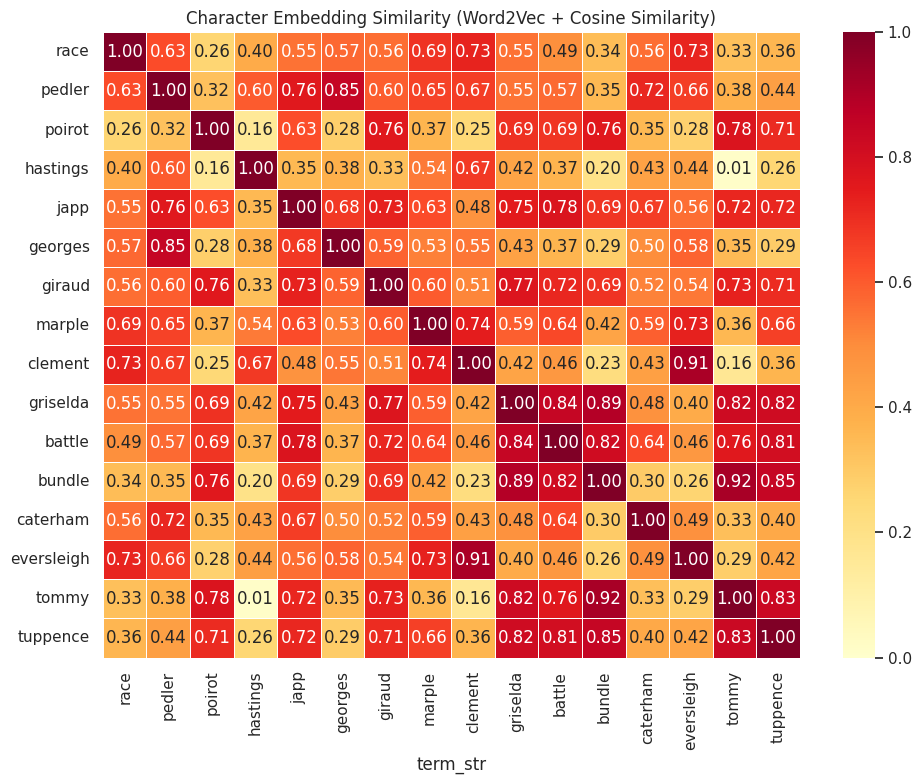

In [58]:
# plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    SIM_CHARS,
    annot=True, # print similarity value as number inside each cell
    fmt='.2f', # format annotation numbers to two decimal places
    cmap='YlOrRd', # color palette
    vmin=0, vmax=1, # anchor color scale to full cosine similarityy range (so that seaborn doesn't auto scale to the data and make small differences look big)
    linewidths=0.5 # put thin glines between cells
)
plt.title('Character Embedding Similarity (Word2Vec + Cosine Similarity)')
plt.tight_layout()
plt.savefig('plots/riff2_character_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

Notice that Hastings has low similarity with almost everyone including Poirot. However, this isn't too surprising given that Hastings is the narrator, so the term string hastings would only show up in dialogue. Poirot on the other hand is constantly referenced in narrative, dialogue, and description. The low Poirot-Hastings similarity is likely a result of this asymmetry of reference rather than a signal that they inhabit different semantic spaces. It may be worth further exploration in the future to see if narrator names in general have different co-occurrence distributions than character names.

This itself an artifact of the inscription decision made at tokenization. By treating all tokens as equivalent we erase the narrator/character distinction that a reader would naturally make.

#### ADD MORE INTERPRETATION

## Riff 3: Books in PCA Space Colored and Shaped by LIB Metadata

### Aggregate PCA Output

In [59]:
DCM_BOOKS = DCM.groupby('book_id').mean()

### Join LIB Features

In [60]:
DCM_BOOKS = DCM_BOOKS.join(LIB[['sleuth', 'work_type', 'genre', 'title']])

In [61]:
DCM_BOOKS['sleuth'] = DCM_BOOKS['sleuth'].fillna('None') # deal with giants bread

### Visualize

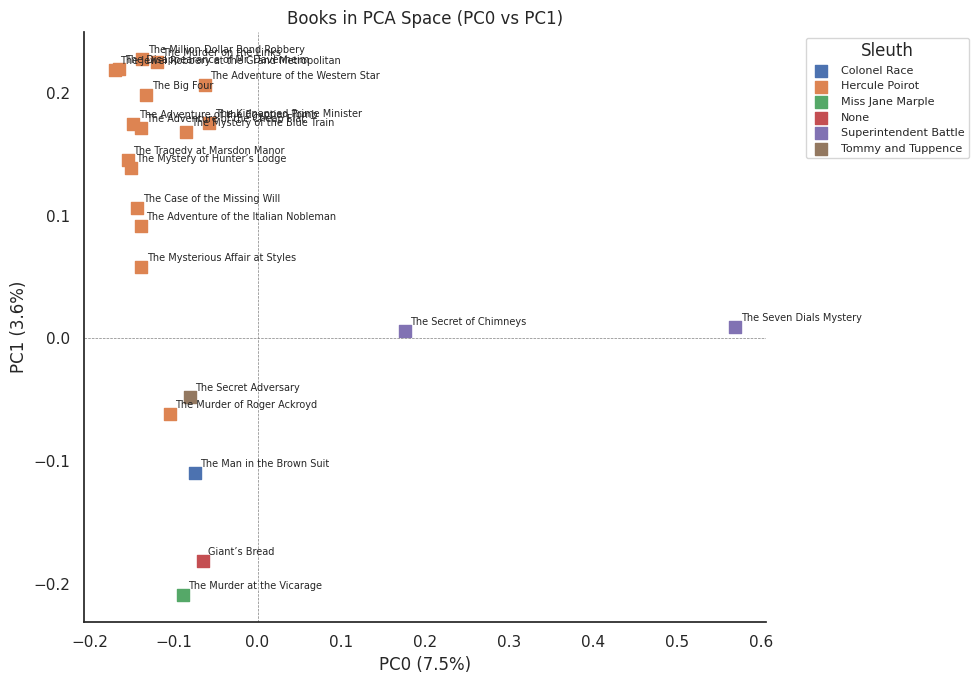

In [62]:
# plot
markers = {'novel': 'o', 'short_story': 's'}

fig, ax = plt.subplots(figsize=(10, 7))

for sleuth, group in DCM_BOOKS.groupby('sleuth'):
    marker = 'o' if group['work_type'].iloc[0] == 'Novel' else 's'
    ax.scatter(group['PC0'], group['PC1'], label=sleuth, marker=marker, s=80)
    for _, row in group.iterrows():
        ax.annotate(row['title'], (row['PC0'], row['PC1']),
                    fontsize=7, ha='left', va='bottom', textcoords='offset points', xytext=(4, 3))

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC0 (7.5%)')
ax.set_ylabel('PC1 (3.6%)')
ax.set_title('Books in PCA Space (PC0 vs PC1)')
ax.legend(title='Sleuth', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig('plots/riff3_pca_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

### PC0 Loadings

In [63]:
LOADINGS['PC0'].sort_values().head(10)  # most negative terms

term_str
monsieur       -0.019026
hastings       -0.017284
madame         -0.017035
colonel        -0.016335
inspector      -0.015167
mademoiselle   -0.013345
train          -0.011194
friend         -0.011174
dr             -0.011143
mother         -0.010769
Name: PC0, dtype: float64

In [64]:
LOADINGS['PC0'].sort_values().tail(10)  # most positive terms

term_str
party        0.003447
dangerous    0.003491
terrace      0.003497
foreign      0.005149
seven        0.011869
lady         0.015305
george       0.027573
lord         0.047462
bill         0.070832
bundle       0.199422
Name: PC0, dtype: float64

### Interpretation